In [1]:
%load_ext autoreload
%autoreload 2
# standard imports
import pandas as pd
import numpy as np
import sys

sys.path.append("..")

In [2]:
from models.prepare import prepare_df

safe_to_drop = ["author_qid", "goodreads_id", "title", "authorLabel"]
shortlists = pd.read_csv("../data/train_novels.csv").drop(columns=safe_to_drop)

df_train = prepare_df(shortlists)
X_train = df_train.copy()
y_train = X_train.pop("n_win")


In [3]:
from sklearn.metrics import f1_score, balanced_accuracy_score
from models.naive import naive_win_counts

N_baseline_runs = 1000
baseline_f1s = np.zeros(N_baseline_runs)
baseline_balanced_accuracy = np.zeros(N_baseline_runs)

for i in range(N_baseline_runs):
    win_counts = naive_win_counts(df_train)
    baseline_f1s[i] = f1_score(y_train > 0, win_counts > 0)
    baseline_balanced_accuracy[i] = balanced_accuracy_score(y_train > 0, win_counts > 0)

In [6]:
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import GroupKFold
from sklearn.base import BaseEstimator
from models.transformers import RowCountEncoder, impute_topicality, cohort_zscore


def build_pipeline(estimator_name: str, estimator: BaseEstimator) -> Pipeline:
    return Pipeline(
        [
            ("impute_topicality", FunctionTransformer(impute_topicality)),
            (
                "encode_author_data",
                RowCountEncoder(["gender", "birth_country"], "work_qid"),
            ),
            (
                "zscore",
                FunctionTransformer(
                    cohort_zscore,
                    kw_args={"columns": ["awards_as_of_year", "topicality"]},
                ),
            ),
            (
                "drop",
                FunctionTransformer(lambda df: df.drop(columns=["work_qid", "month"])),
            ),
            ("imputer", SimpleImputer(strategy="median")),
            (
                estimator_name,
                estimator,
            ),
        ]
    ).set_output(transform="pandas")


In [12]:
from sklearn.model_selection import cross_validate, GroupKFold

def do_cv(model, splitter=None, params=None):
    params = params or {}
    params["groups"] = X_train["year"]
    return cross_validate(
        model,
        X_train,
        y_train > 0,
        cv=splitter or GroupKFold(n_splits=5),
        scoring=["f1", "balanced_accuracy"],
        params=params,
        n_jobs=5,
    )

In [10]:
from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn import config_context

with config_context(enable_metadata_routing=True):
    logistic_model = TunedThresholdClassifierCV(
        build_pipeline(
            "logistic",
            LogisticRegressionCV(
                max_iter=10000,
                fit_intercept=False,
                class_weight="balanced",
                solver="liblinear",
                scoring="roc_auc",
            ).set_fit_request(sample_weight=True),
        ),
        scoring="f1",
    )

    logistic_cv = do_cv(logistic_model, params={"sample_weight": X_train["n_nom_all"]})


In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

with config_context(enable_metadata_routing=True):
    splitter = GroupKFold(n_splits=5)

    dt_model = TunedThresholdClassifierCV(
        build_pipeline(
            "tree",
            GridSearchCV(
                DecisionTreeClassifier(min_samples_leaf=4, class_weight="balanced"),
                param_grid={"max_depth": range(1, 10)},
                cv=splitter,
            ),
        ),
        scoring="f1",
    )

    dt_cv = do_cv( dt_model, splitter=splitter)



In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold

with config_context(enable_metadata_routing=True):
    splitter = StratifiedGroupKFold(n_splits=5)

    rf_model = TunedThresholdClassifierCV(
        build_pipeline(
            "tree",
            GridSearchCV(
                RandomForestClassifier(class_weight="balanced"),
                param_grid={"max_depth": range(1, 10), "n_estimators": [100, 500]},
                scoring="roc_auc",
                cv=splitter,
                n_jobs=2,
            ),
        ),
        scoring="f1",
    )

    rf_cv = do_cv(
        rf_model,
        splitter=splitter,
    )

In [14]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedGroupKFold

with config_context(enable_metadata_routing=True):
    splitter = StratifiedGroupKFold(n_splits=5)

    xgb_model = TunedThresholdClassifierCV(
        build_pipeline(
            "tree",
            GridSearchCV(
                XGBClassifier(),
                param_grid={"max_depth": range(1, 10), "n_estimators": [100, 500]},
                scoring="roc_auc",
                cv=splitter,
                n_jobs=2,
            ),
        ),
        scoring="f1",
    )

    xgb_cv = do_cv(
        xgb_model,
        splitter=splitter,
    )

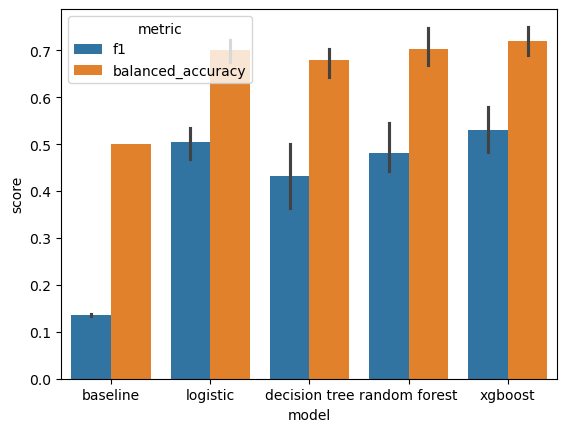

In [17]:
import seaborn as sns
f1_scores = {
    "baseline": baseline_f1s,
    "logistic": logistic_cv["test_f1"],
    "decision tree": dt_cv["test_f1"],
    "random forest": rf_cv["test_f1"],
    "xgboost": xgb_cv["test_f1"],
}
balanced_accuracy_scores = {
    "baseline": baseline_balanced_accuracy,
    "logistic": logistic_cv["test_balanced_accuracy"],
    "decision tree": dt_cv["test_balanced_accuracy"],
    "random forest": rf_cv["test_balanced_accuracy"],
    "xgboost": xgb_cv["test_balanced_accuracy"],
}
performance = pd.concat([
    pd.DataFrame({
        "model": k,
        "metric": "f1",
        "score": v
    })
    for (k, v) in f1_scores.items()
] + [
    pd.DataFrame({
        "model": k,
        "metric": "balanced_accuracy",
        "score": v
    })
    for (k, v) in balanced_accuracy_scores.items()
])

score_plot = sns.barplot(data=performance, x="model", y="score", hue="metric")
# f1_plot.set_ylabel(r"$F_1$")
sns.move_legend(score_plot, "upper left")

Text(0, 0.5, '$F_1$')

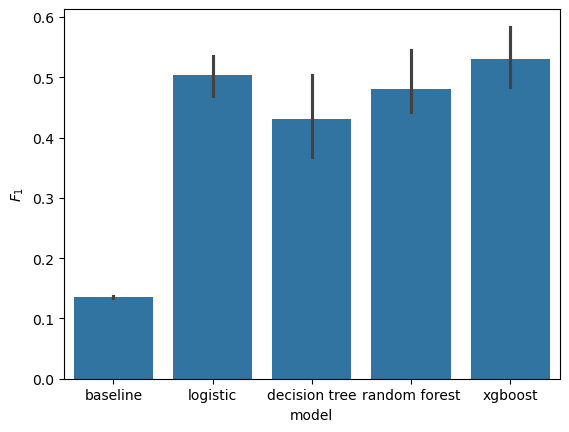

In [18]:
f1_plot = sns.barplot(data=performance[performance["metric"] == "f1"], x="model", y="score")
f1_plot.set_ylabel(r"$F_1$")